In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
df = pd.read_csv(r"C:\Users\veda\Downloads\2) Stock Prices Data Set.csv")

In [15]:
print(df.head())
print(df.info())

           symbol     open     high      low    close     volume  \
date                                                               
2014-01-02   AAPL  79.3828  79.5756  78.8601  79.0185   58791957   
2014-01-03   AAPL  78.9799  79.0999  77.2042  77.2828   98303870   
2014-01-06   AAPL  76.7785  78.1142  76.2285  77.7042  103359151   
2014-01-07   AAPL  77.7599  77.9942  76.8464  77.1481   79432766   
2014-01-08   AAPL  76.9728  77.9371  76.9556  77.6371   64686685   

            Moving_Average  
date                        
2014-01-02             NaN  
2014-01-03             NaN  
2014-01-06             NaN  
2014-01-07             NaN  
2014-01-08             NaN  
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1007 entries, 2014-01-02 to 2017-12-29
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   symbol          1007 non-null   object 
 1   open            1007 non-null   float64
 2   high       

In [6]:
df["date"] = pd.to_datetime(df["date"])

In [7]:
df = df[df["symbol"] == "AAPL"]

In [8]:
df.set_index("date", inplace=True)

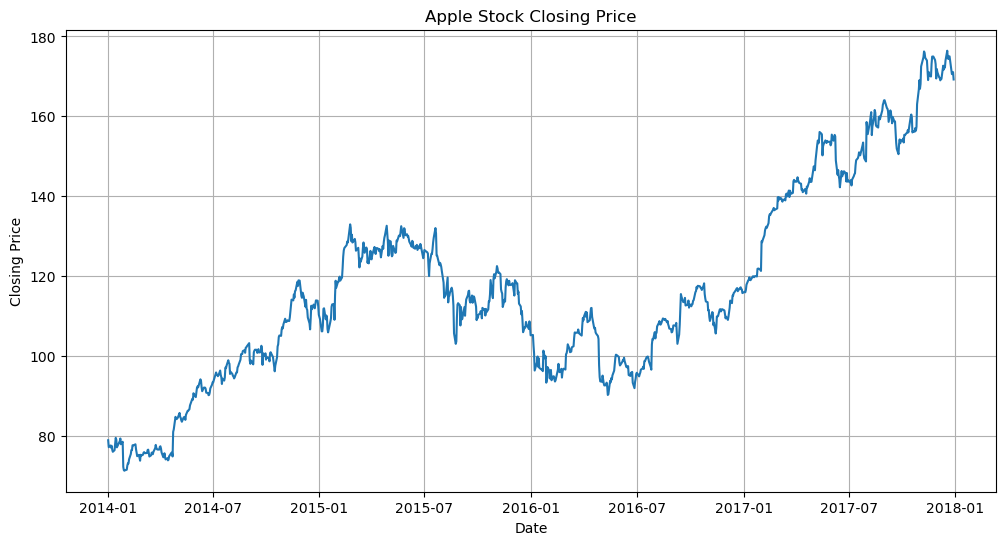

In [10]:
plt.figure(figsize=(12,6))

plt.plot(df["close"])

plt.title("Apple Stock Closing Price")

plt.xlabel("Date")

plt.ylabel("Closing Price")

plt.grid(True)

plt.show()

In [11]:
df["Moving_Average"] = df["close"].rolling(window=30).mean()

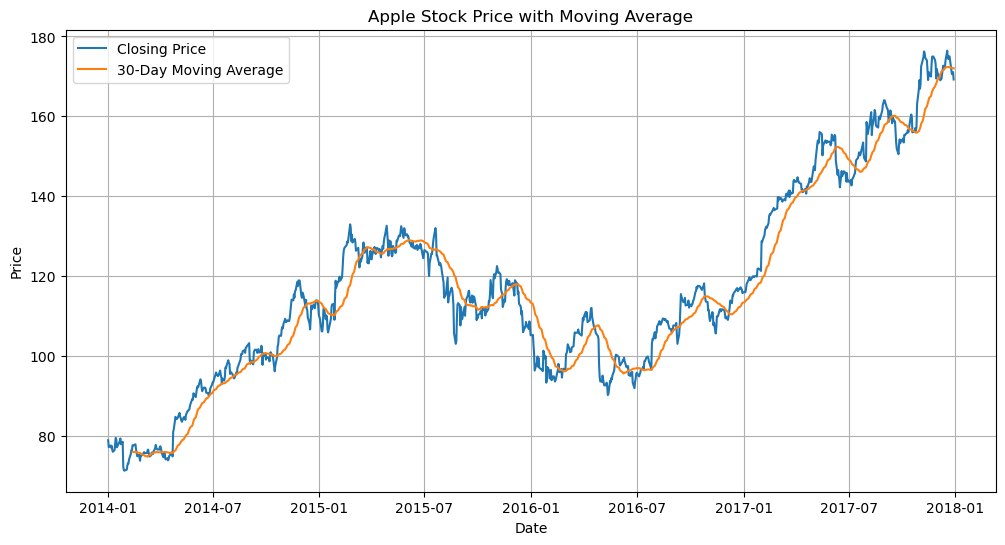

In [12]:
plt.figure(figsize=(12,6))

plt.plot(df["close"], label="Closing Price")

plt.plot(df["Moving_Average"], label="30-Day Moving Average")

plt.title("Apple Stock Price with Moving Average")

plt.xlabel("Date")

plt.ylabel("Price")

plt.legend()

plt.grid(True)

plt.show()

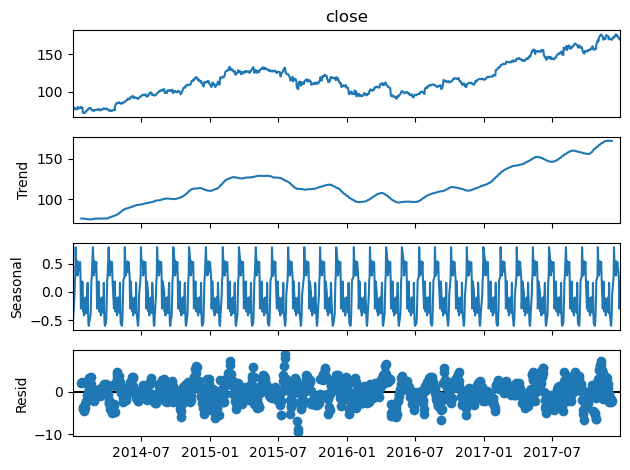

In [13]:
decomposition = seasonal_decompose(
    df["close"],
    model="additive",
    period=30
)

decomposition.plot()

plt.show()